# Customer Churn Prediction

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load dataset

In [2]:
df = pd.read_csv("../data/telco_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Dataset shape

In [3]:
df.shape

(7043, 21)

## 4. Dataset overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 5. Summary statistics

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 6. Data cleaning
Convert TotalCharges to numeric

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [7]:
df["TotalCharges"].isna().sum()

np.int64(11)

## 7. Handle missing values

After converting `TotalCharges` to numeric, some values became `NaN`.
This happens for customers with `tenure = 0`.

Since there are only a few cases, we remove these rows from the dataset.

In [8]:
df = df.dropna()

In [9]:
df.shape

(7032, 21)

## 8. Remove identifier column

`customerID` is only a unique identifier for each customer and does not contain predictive information, so we remove it from the dataset.

In [10]:
df = df.drop("customerID", axis=1)

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.shape

(7032, 20)

## 9. Target variable distribution

Before training models, we examine the distribution of the target variable (`Churn`) to understand the class balance.

In [13]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

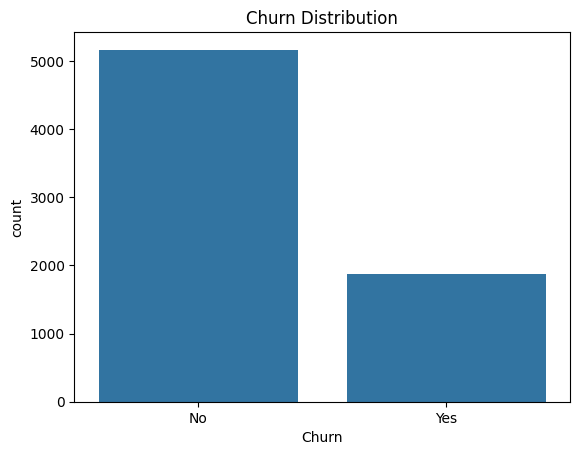

In [14]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

## 10. Encode target variable

Machine learning models require numerical inputs, so we convert the target variable `Churn` into a binary format.

In [15]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [16]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## 11. Relationship between numerical variables and churn

We compare the average values of key numerical features between customers who churned and those who stayed.

In [17]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.650010,61.307408,2555.344141
1,17.979133,74.441332,1531.796094


### Numerical Features Insight

Customers who churn tend to have **much shorter tenure** and **higher monthly charges** than customers who stay.

This suggests that newer and more expensive customers are more likely to leave.

## 12. Churn by contract type

We analyze how churn varies depending on the type of contract.

In [18]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


### Insight

Customers with **month-to-month contracts** show a much higher churn rate (~43%) compared to customers with long-term contracts.

This suggests that **contract commitment strongly reduces churn**.

## 13. Encode binary categorical variables

Some columns contain Yes/No values.  
We convert these variables into numerical format for machine learning models.

In [19]:
yes_no_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [21]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## 14. One-hot encode categorical variables

The remaining categorical variables are transformed into numerical features using one-hot encoding.
This allows machine learning models to use them properly.

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [23]:
df_encoded.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [24]:
df_encoded.shape

(7032, 31)

## 15. Define features and target

We separate the dataset into:

- X → input features
- y → target variable (Churn)

In [25]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [26]:
X.shape

(7032, 30)

## 16. Train-test split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
X_train.shape, X_test.shape

((5625, 30), (1407, 30))

## 17. Logistic Regression baseline model

We start with Logistic Regression as a baseline model.

Since this model is sensitive to feature scale, we standardize the input features before training.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
y_pred_log = log_model.predict(X_test_scaled)

## 18. Evaluate Logistic Regression

We evaluate the baseline model using standard classification metrics.

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

In [35]:
accuracy_score(y_test, y_pred_log)

0.7874911158493249

In [36]:
precision_score(y_test, y_pred_log)

0.6205787781350482

In [37]:
recall_score(y_test, y_pred_log)

0.516042780748663

In [38]:
y_pred_log_proba = log_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_score(y_test, y_pred_log_proba)

0.8319235288940887

In [39]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Logistic Regression Insight

The Logistic Regression model achieves a ROC-AUC of about **0.83**, indicating good ability to distinguish between customers who churn and those who stay.

However, recall for churned customers is relatively low (~0.52), meaning that the model misses a significant portion of customers who actually churn.

This suggests that more flexible models such as tree-based methods may improve performance.

## 19. Random Forest model

Tree-based models can capture non-linear relationships between features, which often improves performance in churn prediction problems.

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [42]:
y_pred_rf = rf_model.predict(X_test)

## 20. Evaluate Random Forest

In [43]:
accuracy_score(y_test, y_pred_rf)

0.7839374555792467

In [44]:
precision_score(y_test, y_pred_rf)

0.6258992805755396

In [45]:
recall_score(y_test, y_pred_rf)

0.46524064171123

In [46]:
y_pred_rf_proba = rf_model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_rf_proba)

0.8182866475816764

In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



### Random Forest Insight

Random Forest does not improve performance over Logistic Regression in this dataset.

The ROC-AUC is slightly lower (~0.82 vs ~0.83), and recall for churned customers is also worse.

This suggests that the relationships in the data may be relatively linear or that the current Random Forest configuration is not fully optimized.

## 21. XGBoost model

Gradient boosting models such as XGBoost are often among the most powerful algorithms for tabular machine learning problems.

In [48]:
from xgboost import XGBClassifier

In [49]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [50]:
y_pred_xgb = xgb_model.predict(X_test)

## 22. Evaluate XGBoost

In [51]:
accuracy_score(y_test, y_pred_xgb)

0.8024164889836531

In [52]:
precision_score(y_test, y_pred_xgb)

0.6621621621621622

In [53]:
recall_score(y_test, y_pred_xgb)

0.5240641711229946

In [54]:
y_pred_xgb_proba = xgb_model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_xgb_proba)

0.8332358376774982

In [55]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



### XGBoost Insight

XGBoost provides the best overall performance among the tested models.

It achieves the highest accuracy (~0.80) and precision for churn prediction, while maintaining a ROC-AUC of about 0.83.

This confirms the effectiveness of gradient boosting models for tabular machine learning problems.

## 23. Model comparison

In [56]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_log_proba),
        roc_auc_score(y_test, y_pred_rf_proba),
        roc_auc_score(y_test, y_pred_xgb_proba)
    ]
})

model_results = model_results.sort_values("ROC-AUC", ascending=False)
model_results[["Accuracy", "ROC-AUC"]] = model_results[["Accuracy", "ROC-AUC"]].round(3)

model_results

,Model,Accuracy,ROC-AUC
2,XGBoost,0.802,0.833
0,Logistic Regression,0.787,0.832
1,Random Forest,0.784,0.818


## 24. XGBoost Feature Importance

We examine which features contribute most to churn prediction using the XGBoost model.

In [57]:
import pandas as pd

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

InternetService_Fiber optic       0.401272
Contract_Two year                 0.161025
Contract_One year                 0.118053
InternetService_No                0.076087
StreamingMovies_Yes               0.036531
tenure                            0.031164
TechSupport_Yes                   0.020249
PaymentMethod_Electronic check    0.018790
OnlineSecurity_Yes                0.018222
PaperlessBilling                  0.013137
dtype: float32

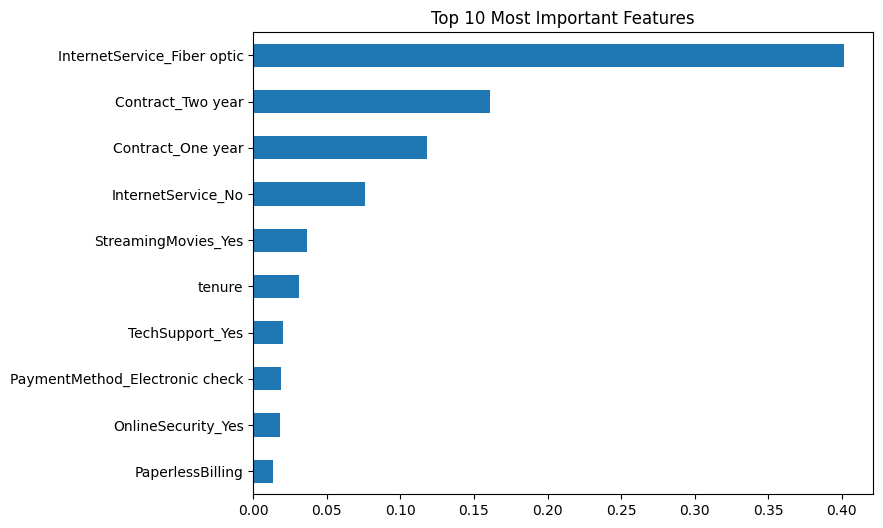

In [58]:
plt.figure(figsize=(8,6))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Most Important Features")
plt.show()

### Feature Importance Insight

The most important feature in the model is **Fiber Optic internet service**, suggesting that customers with this service are more likely to churn.

Contract length is also highly influential: customers with **one-year or two-year contracts are much less likely to churn**.

Additionally, **tenure** appears among the top predictors, confirming that newer customers are more likely to leave.

## 25. Model Explainability with SHAP

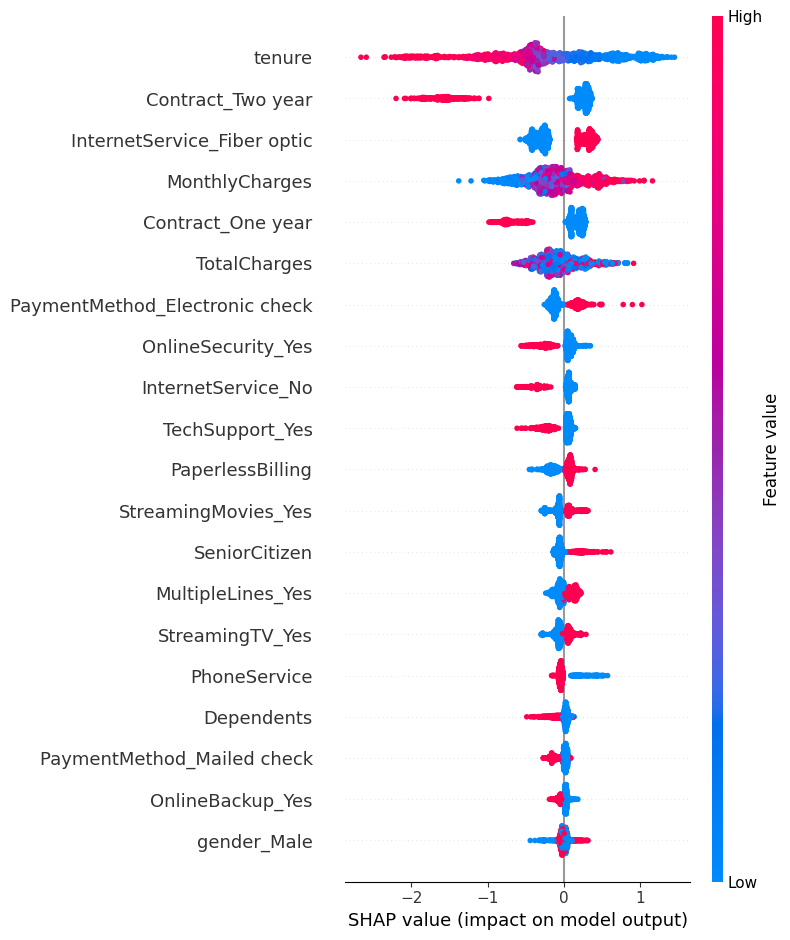

In [59]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP Insight

SHAP values provide a detailed explanation of how features influence churn predictions.

Customers with **short tenure**, **higher monthly charges**, and **fiber optic internet service** are more likely to churn.

On the other hand, **longer contracts and longer tenure significantly reduce churn risk**.

These insights align with typical customer behavior in telecom services, where long-term contracts increase customer retention.

## 26. ROC Curve Comparison

We compare the ROC curves of the three models to visualize their ability to distinguish churn vs non-churn.

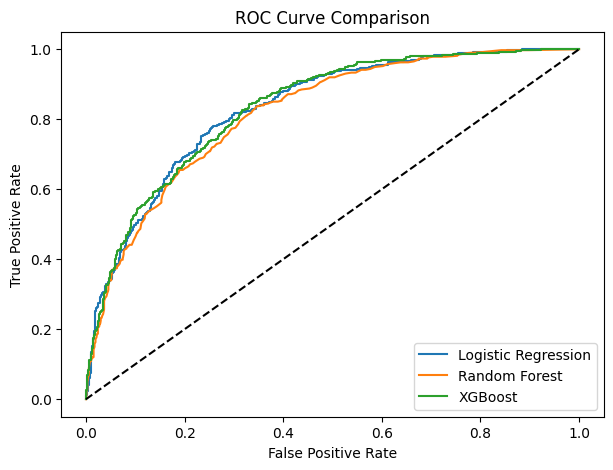

In [60]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_proba)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## 27. Threshold Tuning

Instead of using the default 0.5 probability threshold, we evaluate how different thresholds affect model performance.

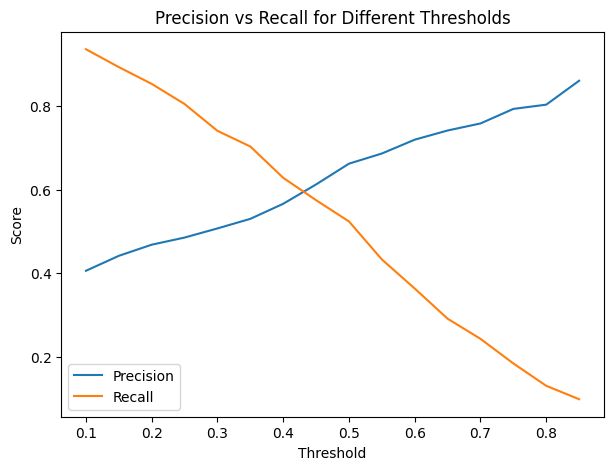

In [61]:
thresholds = np.arange(0.1, 0.9, 0.05)

precision_list = []
recall_list = []

for t in thresholds:
    
    preds = (y_pred_xgb_proba >= t).astype(int)
    
    precision_list.append(precision_score(y_test, preds))
    recall_list.append(recall_score(y_test, preds))


plt.figure(figsize=(7,5))

plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall for Different Thresholds")
plt.legend()

plt.show()

### Threshold Insight

The default classification threshold is 0.5, but adjusting the threshold can significantly change model behavior.

Lower thresholds increase **recall**, meaning more churners are detected, but at the cost of lower precision.

Higher thresholds increase **precision**, reducing false positives but missing more churners.

Around a threshold of **0.45**, the model achieves a balanced trade-off between precision and recall.

## 28. Conclusion

In this project we built several machine learning models to predict customer churn for a telecommunications company.

Key findings:

- Customers with **month-to-month contracts** have significantly higher churn rates.
- Customers with **shorter tenure** are more likely to churn.
- **Fiber optic internet service** appears strongly associated with churn.

Among the tested models, **XGBoost achieved the best overall performance**, reaching an accuracy of about **80%** and a ROC-AUC of **~0.83**.

These results show that machine learning can effectively identify customers at risk of leaving, which could help companies design targeted retention strategies.

These findings could support customer retention campaigns by helping identify high-risk customers before they leave.